In [24]:
%%writefile main.cpp
#include <iostream>
#include <vector>
#include <thread>
#include <opencv2/opencv.hpp>

// Her çekirdeğin kendi ROI parçası için histogram hesaplama fonksiyonu
// hist[256]: 0'dan 255'e kadar her parlaklığın sayısını tutar
void histogram_hesapla(cv::Mat roi, int bolum_no, std::vector<int>& hist) {
    hist.assign(256, 0); // 256 elemanlı diziyi sıfırla

    for (int y = 0; y < roi.rows; y++) {
        for (int x = 0; x < roi.cols; x++) {
            uchar parlaklik = roi.at<uchar>(y, x);
            hist[parlaklik]++; // İlgili parlaklık değerinin sayacını 1 artır
        }
    }
    std::cout << "Bolum " << bolum_no << " histogrami hesaplandi. Toplam Piksel: "
              << roi.rows * roi.cols << std::endl;
}

int main() {
    // 1. Resmi gri seviye oku
    cv::Mat img = cv::imread("resim.jpg", cv::IMREAD_GRAYSCALE);
    if (img.empty()) {
        std::cout << "HATA: resim.jpg bulunamadi!" << std::endl;
        return -1;
    }

    int yarim_w = img.cols / 2;
    int yarim_h = img.rows / 2;

    // 2. Resmi 4 eşit ROI parçasına ayır
    cv::Mat roi1 = img(cv::Rect(0, 0, yarim_w, yarim_h));               // Sol Üst
    cv::Mat roi2 = img(cv::Rect(yarim_w, 0, yarim_w, yarim_h));         // Sağ Üst
    cv::Mat roi3 = img(cv::Rect(0, yarim_h, yarim_w, yarim_h));         // Sol Alt
    cv::Mat roi4 = img(cv::Rect(yarim_w, yarim_h, yarim_w, yarim_h));   // Sağ Alt

    // 4 bölge için 256'şar elemanlı histogram dizileri
    std::vector<int> hist1, hist2, hist3, hist4;

    // 3. 4 Çekirdeğe dağıtarak paralel hesaplat
    std::thread t1(histogram_hesapla, roi1, 1, std::ref(hist1));
    std::thread t2(histogram_hesapla, roi2, 2, std::ref(hist2));
    std::thread t3(histogram_hesapla, roi3, 3, std::ref(hist3));
    std::thread t4(histogram_hesapla, roi4, 4, std::ref(hist4));

    t1.join();
    t2.join();
    t3.join();
    t4.join();

    // 4. Sonuçları Python'da grafik çizdirebilmek için bir metin dosyasına yaz
    FILE* f = fopen("histogram_verileri.txt", "w");
    for (int i = 0; i < 256; i++) {
        fprintf(f, "%d %d %d %d\n", hist1[i], hist2[i], hist3[i], hist4[i]);
    }
    fclose(f);

    std::cout << "\nHistogram sonuclari 'histogram_verileri.txt' dosyasina kaydedildi!" << std::endl;
    return 0;
}

Overwriting main.cpp


In [25]:
!g++ -std=c++17 main.cpp -o app `pkg-config --cflags --libs opencv4` -pthread
!./app

Bolum 1 histogrami hesaplandi. Toplam Piksel: 250000
Bolum 4 histogrami hesaplandi. Toplam Piksel: 250000
Bolum 2 histogrami hesaplandi. Toplam Piksel: 250000
Bolum 3 histogrami hesaplandi. Toplam Piksel: 250000

Histogram sonuclari 'histogram_verileri.txt' dosyasina kaydedildi!


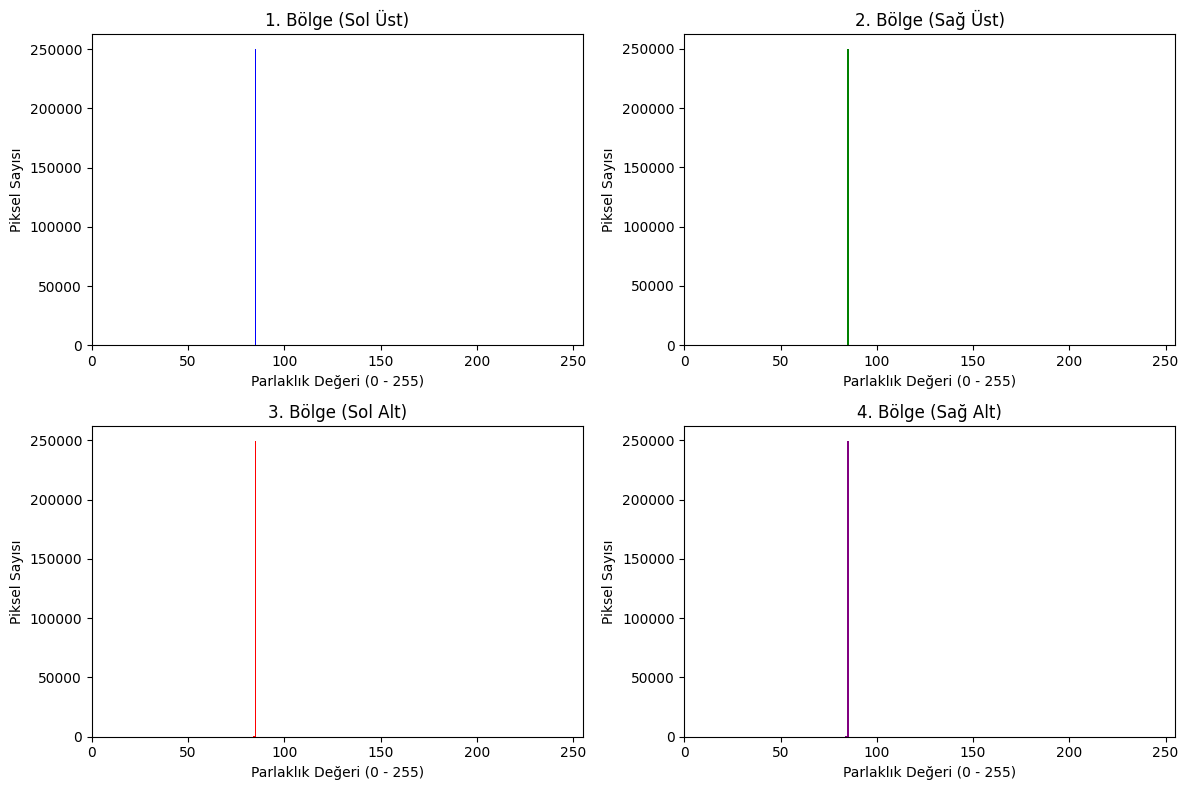

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# C++ tarafından üretilen veriyi oku
veriler = np.loadtxt('histogram_verileri.txt')

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
bolgeler = [("1. Bölge (Sol Üst)", 0, 0, 'blue'),
            ("2. Bölge (Sağ Üst)", 0, 1, 'green'),
            ("3. Bölge (Sol Alt)", 1, 0, 'red'),
            ("4. Bölge (Sağ Alt)", 1, 1, 'purple')]

for baslik, r, c, renk in bolgeler:
    idx = r * 2 + c
    axs[r, c].bar(range(256), veriler[:, idx], color=renk, width=1.0)
    axs[r, c].set_title(baslik)
    axs[r, c].set_xlabel("Parlaklık Değeri (0 - 255)")
    axs[r, c].set_ylabel("Piksel Sayısı")
    axs[r, c].set_xlim([0, 255])

plt.tight_layout()
plt.show()